# 01 — Data & Task Overview

What does the dataset look like? How many animals, sessions, trials?
What distributions did each animal experience, and in what order?

This notebook is pure exploration — no model fitting, no inference.


## Setup


In [1]:
%matplotlib inline
from shared_setup import *
import pandas as pd

experiment, info = load_data()
print(f"Mode: {info['mode']}")
print(f"Animals: {experiment.n_animals}")
print(f"Total sessions: {sum(a.n_sessions for a in experiment.animals.values())}")

Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-01)
Mode: snapshot
Animals: 22
Total sessions: 1185


## Cohort Summary Table

One row per animal: session counts by stage and distribution,
total trials, date range, opto status.


In [2]:
rows = []
for aid, animal in sorted(experiment.animals.items()):
    sessions = list(animal.sessions)
    stages = [s.stage for s in sessions]
    dists = [s.distribution for s in sessions]
    has_opto = any(s.trials.opto_on.any() for s in sessions if hasattr(s.trials, 'opto_on'))
    dates = [s.date for s in sessions if s.date is not None]

    rows.append({
        'animal_id': aid,
        'n_sessions': len(sessions),
        'n_trials': sum(s.n_trials for s in sessions),
        'n_uniform': sum(1 for d in dists if d and 'uniform' in d.lower()),
        'n_hard_a': sum(1 for d in dists if d and 'hard' in d.lower() and 'a' in d.lower()),
        'n_hard_b': sum(1 for d in dists if d and 'hard' in d.lower() and 'b' in d.lower()),
        'has_opto': has_opto,
        'first_date': min(dates).isoformat() if dates else '',
        'last_date': max(dates).isoformat() if dates else '',
    })

cohort_df = pd.DataFrame(rows)
print(cohort_df.to_string(index=False))


animal_id  n_sessions  n_trials  n_uniform  n_hard_a  n_hard_b  has_opto first_date  last_date
     SS01          81     39039         46        35        22     False 2025-11-15 2026-05-12
     SS02          20      7897         20         0         0     False 2025-11-16 2026-01-15
     SS04         100     44632         63        35        22     False 2025-11-15 2026-05-12
     SS05          73     26611         38        35        22     False 2026-01-21 2026-05-12
     SS06          72     27013         37        35        22     False 2026-01-21 2026-05-12
     SS07          73     26528         38        35        22     False 2026-01-21 2026-05-12
     SS08          73     30017         42        31        18     False 2026-01-21 2026-05-12
     SS09          63     22267         29        34        22     False 2026-01-30 2026-05-11
     SS10          63     17335         63         0         0     False 2026-01-30 2026-05-12
     SS11          63     20695         31        

## Distribution Timeline

For each animal, show the sequence of stimulus distributions across sessions.
Opto animals follow: Uniform → Hard-A (opto) → Hard-B (opto) → ... repeating.


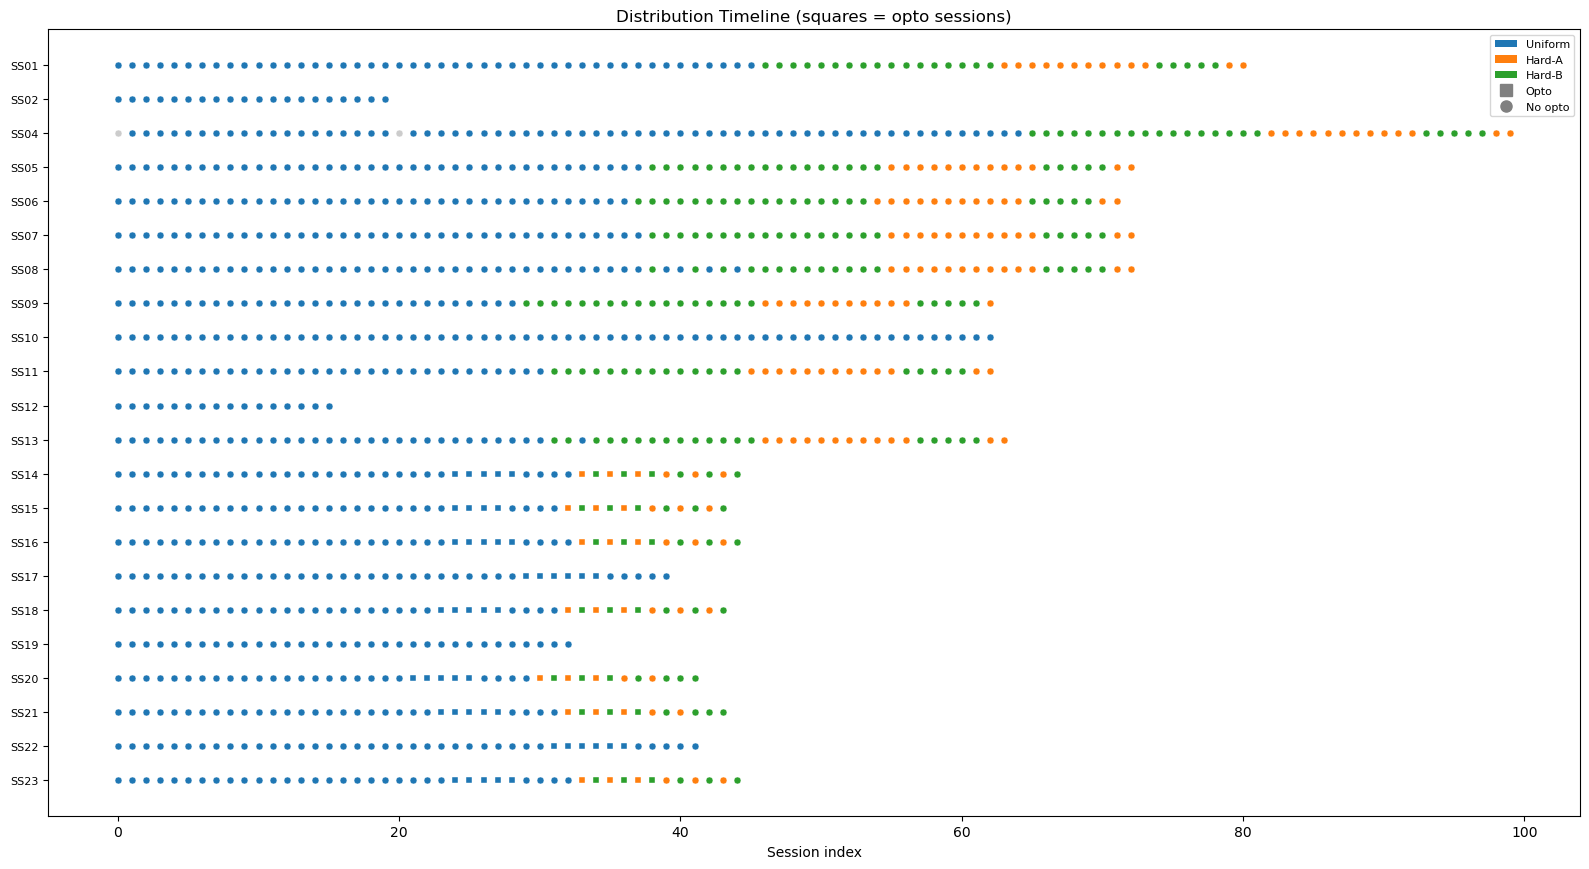

In [3]:
fig, ax = plt.subplots(figsize=(16, max(4, experiment.n_animals * 0.4)))

dist_colours = {
    'Uniform': PALETTE[0],
    'Hard-A': PALETTE[1],
    'Hard-B': PALETTE[2],
}

animal_ids = sorted(experiment.animals.keys())
for y, aid in enumerate(animal_ids):
    animal = experiment.get_animal(aid)
    for i, sess in enumerate(animal.sessions):
        dist = sess.distribution or 'Unknown'
        # Match distribution name flexibly
        colour = '#CCCCCC'
        for key, col in dist_colours.items():
            if key.lower().replace('-', '') in dist.lower().replace('-', '').replace('_', ''):
                colour = col
                break

        marker = 's' if hasattr(sess.trials, 'opto_on') and sess.trials.opto_on.any() else 'o'
        ax.scatter(i, y, c=colour, marker=marker, s=25, edgecolors='white', linewidth=0.3)

ax.set_yticks(range(len(animal_ids)))
ax.set_yticklabels(animal_ids, fontsize=8)
ax.set_xlabel('Session index')
ax.set_title('Distribution Timeline (squares = opto sessions)')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [Patch(facecolor=c, label=k) for k, c in dist_colours.items()]
handles.append(Line2D([0], [0], marker='s', color='grey', ls='', ms=8, label='Opto'))
handles.append(Line2D([0], [0], marker='o', color='grey', ls='', ms=8, label='No opto'))
ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Per-Animal Psychometric Curves (Expert Uniform)

Pooled psychometric for each animal's expert uniform sessions.


In [ ]:
animals_with_expert = []
for aid in sorted(experiment.animals.keys()):
    animal = experiment.get_animal(aid)
    try:
        sessions = select_sessions(animal, preset='uniform')
        if len(sessions) >= 3:
            animals_with_expert.append((aid, sessions))
    except Exception:
        pass

n = len(animals_with_expert)
if n == 0:
    print('No animals with expert uniform sessions found.')
else:
    n_cols = min(4, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = np.atleast_2d(axes)

    for idx, (aid, sessions) in enumerate(animals_with_expert):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        clean = filter_trials(sessions)
        psych = compute_psychometric(clean, mode='pooled')
        plot_psychometric(psych, ax=ax, color='black', title=f'{aid} ({len(clean)}s)', show_ci=True, show_individual=True)

    # Hide unused
    for idx in range(n, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row, col].set_visible(False)

    fig.suptitle('Expert Uniform Psychometrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


No animals with expert uniform sessions found.


## Accuracy Trajectories (All Sessions)

Per-animal accuracy across all sessions, coloured by distribution.


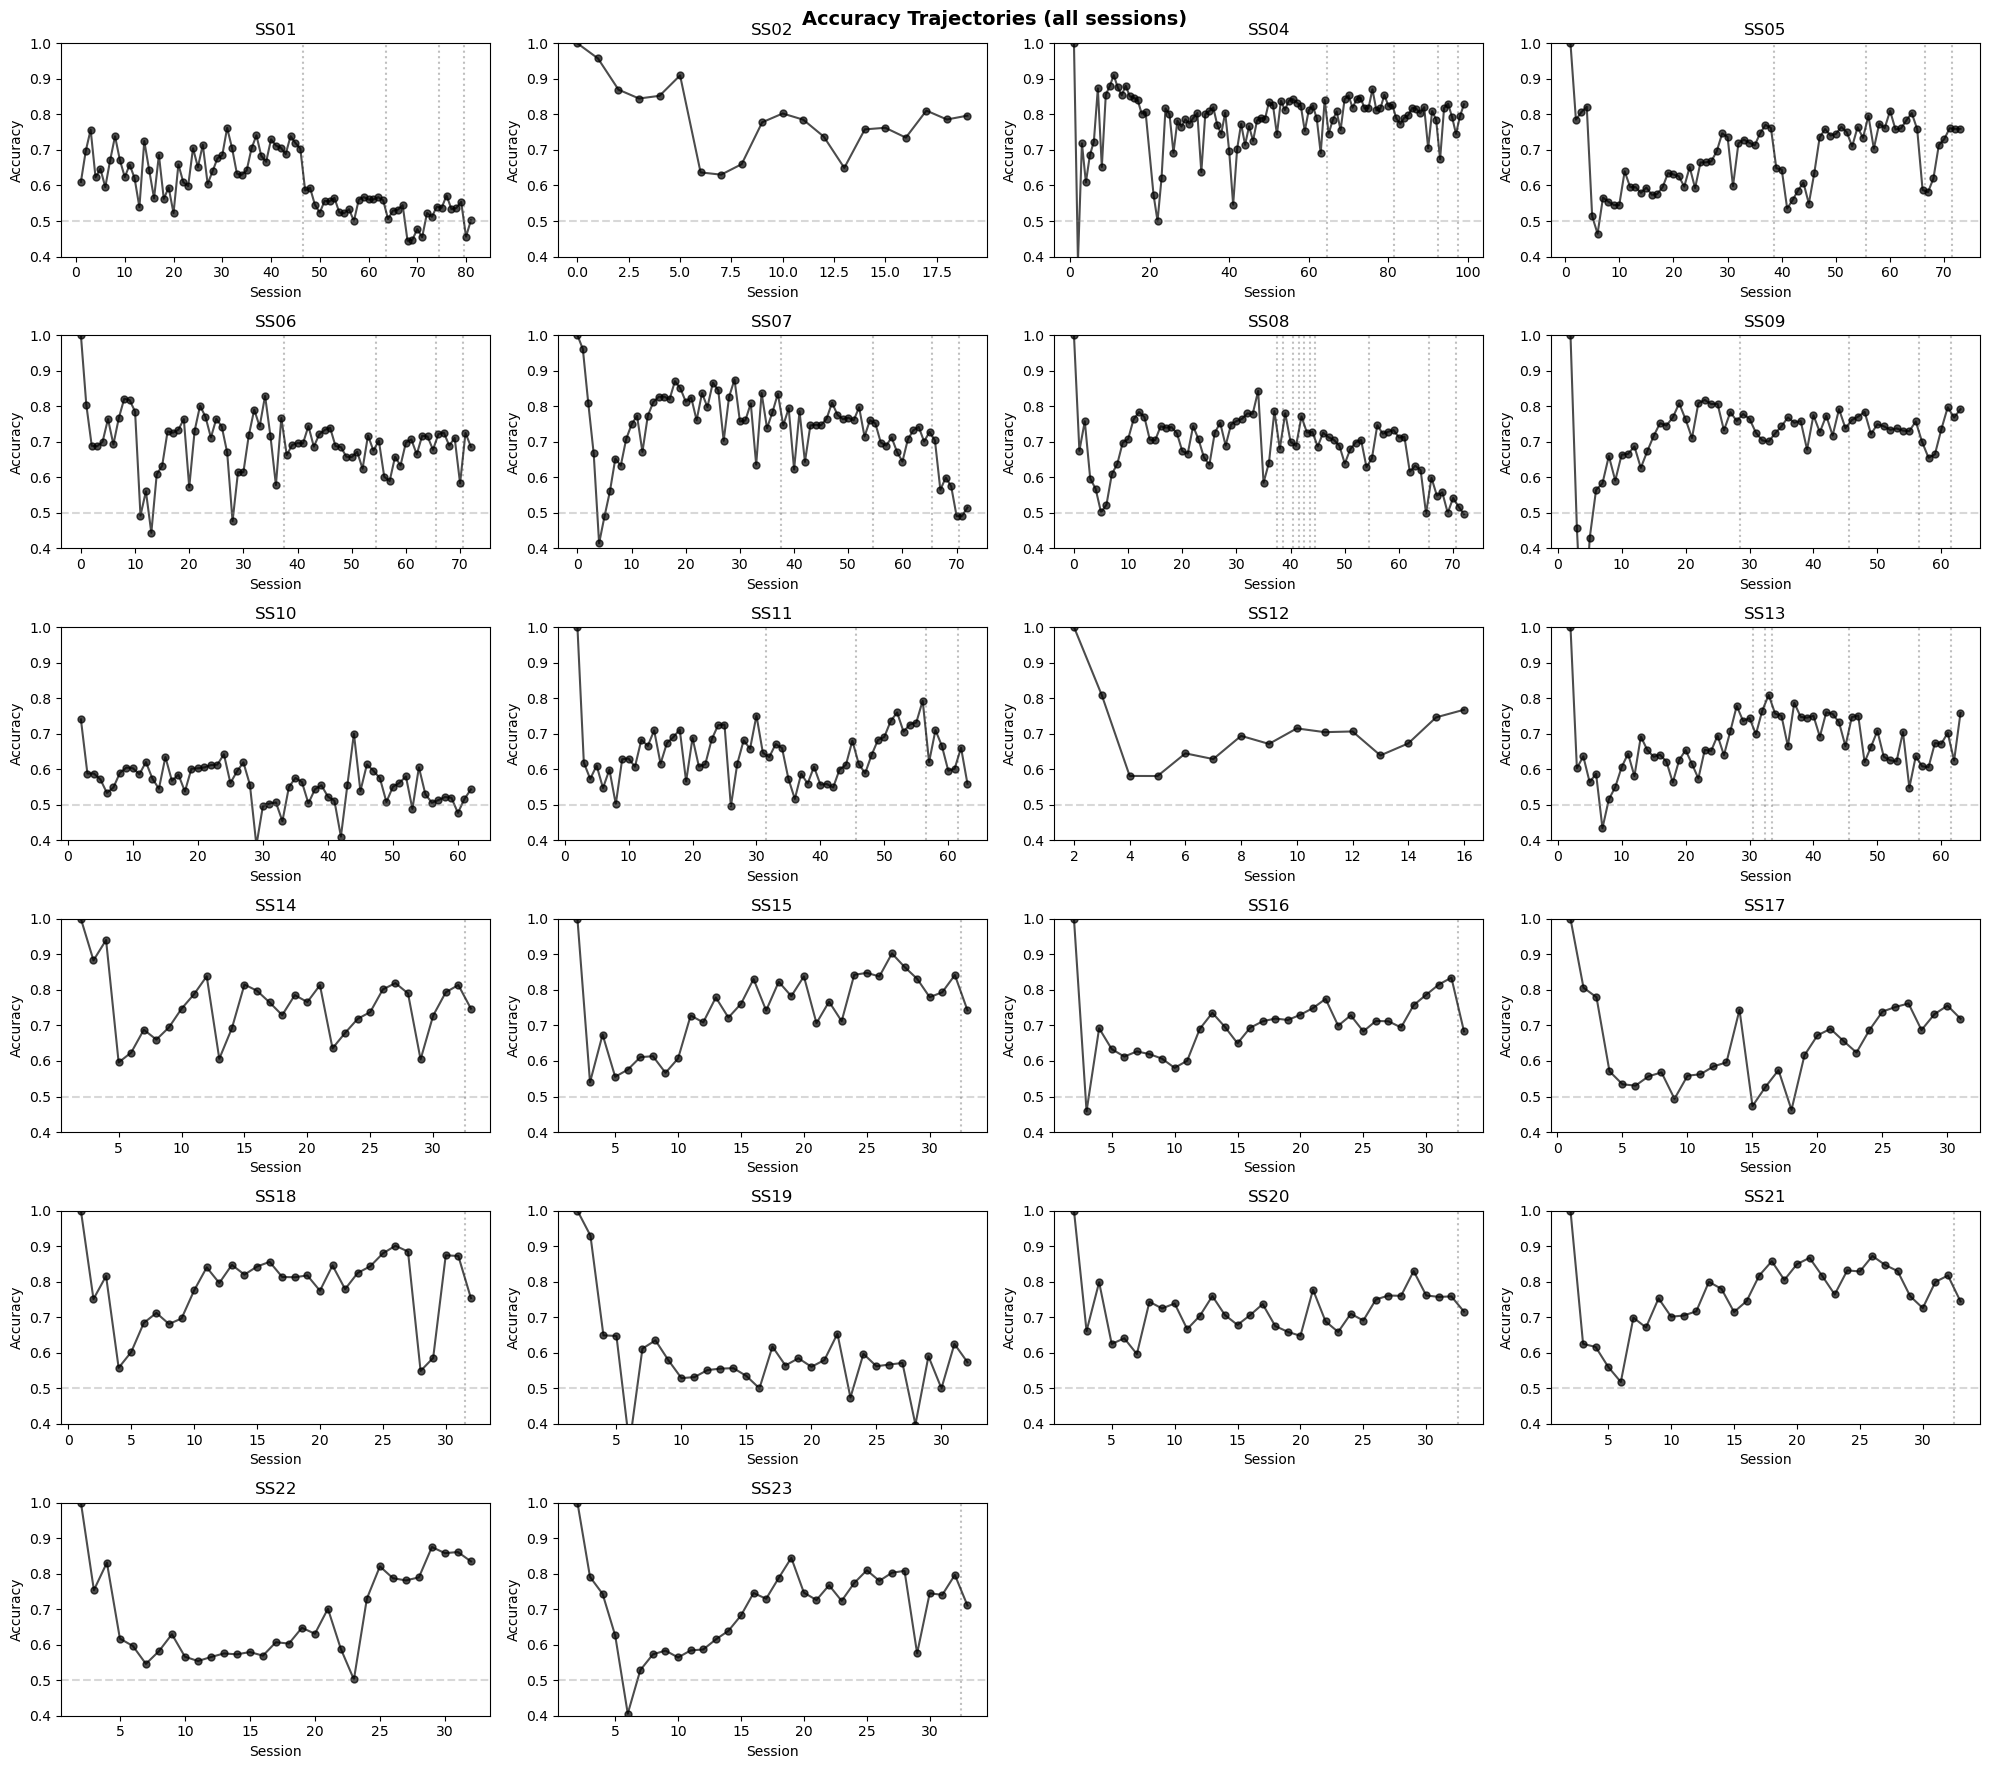

In [5]:
n = experiment.n_animals
n_cols = min(4, n)
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)

for idx, aid in enumerate(sorted(experiment.animals.keys())):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    animal = experiment.get_animal(aid)
    sessions = list(animal.sessions)
    clean = filter_trials(sessions)

    traj = compute_trajectory(clean, stat_names=['accuracy'])
    plot_trajectory(traj, 'accuracy', ax=ax, color='black', title=aid,
                    show_distribution_boundaries=True)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, ls='--', color='grey', alpha=0.3)

for idx in range(n, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

fig.suptitle('Accuracy Trajectories (all sessions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Expert Uniform: Update Matrices

Pooled UM per animal for expert uniform sessions.


In [6]:
if animals_with_expert:
    n = len(animals_with_expert)
    n_cols = min(4, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
    axes = np.atleast_2d(axes)

    for idx, (aid, sessions) in enumerate(animals_with_expert):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        clean = filter_trials(sessions)
        um = compute_um(clean)
        plot_um(um, ax=ax, title=aid)

    for idx in range(n, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row, col].set_visible(False)

    fig.suptitle('Expert Uniform Update Matrices', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Session Raster — Example Animal

Trial-by-trial view for one session.


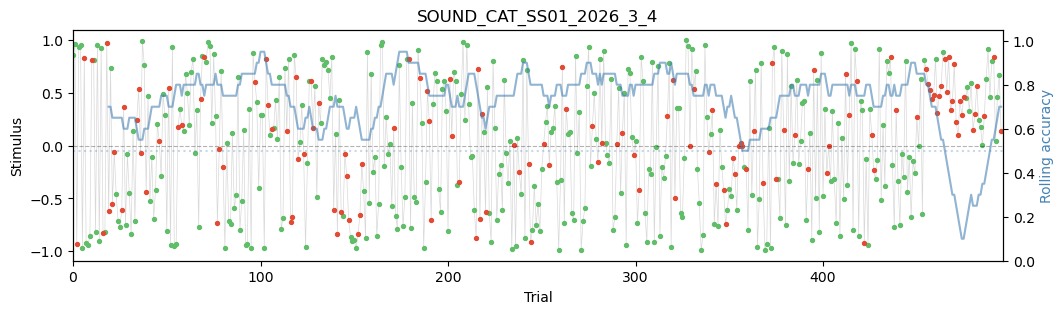

In [17]:
# Pick first animal with data
aid = sorted(experiment.animals.keys())[0]
animal = experiment.get_animal(aid)
sessions = filter_trials(list(animal.sessions))

if sessions:
    raster = compute_session_raster(sessions[40])
    fig, ax = plot_session_raster(raster, window=20)
    plt.show()


## Summary Statistics Distribution

Per-session stats across the cohort.


In [18]:
all_stats = []
for aid in sorted(experiment.animals.keys()):
    animal = experiment.get_animal(aid)
    try:
        sessions = select_sessions(animal, preset='expert_uniform')
        clean = filter_trials(sessions)
        for sess in clean:
            arrays = sess.get_arrays()
            s = compute_summary_stats(
				choices=arrays['choices'], stimuli=arrays['stimuli'],
				categories=arrays['categories'],
				stat_names=['accuracy', 'psychometric', 'recency', 'win_stay'],
				return_dict=True,
			)
            s['animal_id'] = aid
            all_stats.append(s)
    except Exception:
        pass

if all_stats:
    stats_df = pd.DataFrame(all_stats)
    stat_cols = ['accuracy', 'psychometric', 'recency', 'win_stay', 'side_bias']

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, col in zip(axes.flat, stat_cols):
        vals = stats_df[col].dropna()
        ax.hist(vals, bins=20, color=PALETTE[0], alpha=0.7, edgecolor='white')
        ax.axvline(vals.median(), color='black', ls='--', lw=1.5)
        ax.set_title(f'{col} (median={vals.median():.3f})', fontsize=10)
        ax.set_xlabel(col)
    fig.suptitle('Expert Uniform Session Stats', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No expert sessions found.')


No expert sessions found.


In [19]:
# --- Summary Statistics Diagnostic ---
# Check which stats produce NaN or have degenerate distributions,
# session by session across all animals.

from behav_utils.analysis.summary_stats import (
    compute_summary_stats, get_stat_names_expanded,
)
from scripts.config import SBI_STATS

stat_names = list(SBI_STATS)
expanded = get_stat_names_expanded(stat_names)
n_stats = len(expanded)

# Collect per-session stats across all animals
rows = []
for animal_name in experiment.animals:
    animal = experiment.get_animal(animal_name)
    sessions = select_sessions(animal, 'expert_uniform')
    if not sessions:
        continue
    clean = filter_trials(sessions)
    for s_idx, sess in enumerate(clean):
        stim = sess.trials.stimulus
        ch = sess.trials.choice
        cat = sess.trials.category
        valid = np.isfinite(ch)
        if valid.sum() < 20:
            continue
        stats = compute_summary_stats(
            ch[valid], stim[valid], cat[valid],
            stat_names=stat_names, return_dict=False)
        for j, val in enumerate(stats):
            rows.append({
                'animal': animal.animal_id,
                'session': s_idx,
                'stat': expanded[j],
                'value': val,
            })

stats_df = pd.DataFrame(rows)
print(f'{len(stats_df)} stat observations '
      f'({stats_df["animal"].nunique()} animals, '
      f'{stats_df["session"].nunique()} max sessions)')

# --- NaN rate per stat ---
nan_summary = (
    stats_df.groupby('stat')['value']
    .apply(lambda x: x.isna().mean())
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'value': 'nan_rate'})
)
nan_summary['pct'] = (nan_summary['nan_rate'] * 100).round(1)

print('\n=== NaN Rate Per Stat ===')
for _, row in nan_summary.iterrows():
    flag = ' ← DROP' if row['nan_rate'] > 0.3 else ''
    if row['nan_rate'] > 0:
        print(f'  {row["stat"]:<30} {row["pct"]:>5.1f}%{flag}')
if (nan_summary['nan_rate'] == 0).all():
    print('  All stats finite for all sessions.')

# --- Distribution boxplots ---
# Show distribution of each stat across sessions (excluding NaN)
fig, axes = plt.subplots(
    1 + n_stats // 7, 7,
    figsize=(20, 3 * (1 + n_stats // 7)),
    squeeze=False,
)
for i, stat in enumerate(expanded):
    ax = axes[i // 7, i % 7]
    vals = stats_df.loc[stats_df['stat'] == stat, 'value'].dropna()
    if len(vals) > 0:
        ax.hist(vals, bins=20, color=PALETTE[0], alpha=0.7, edgecolor='white')
    ax.set_title(stat, fontsize=8)
    ax.tick_params(labelsize=6)
# Hide empty axes
for i in range(n_stats, axes.size):
    axes.flat[i].set_visible(False)
fig.suptitle('Summary Stat Distributions (per session)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Constant stats (zero variance) ---
const_stats = (
    stats_df.groupby('stat')['value']
    .apply(lambda x: x.dropna().std())
    .reset_index()
    .rename(columns={'value': 'std'})
)
const_stats = const_stats[const_stats['std'] < 1e-10]
if len(const_stats) > 0:
    print('\n=== Constant Stats (zero variance) ===')
    for _, row in const_stats.iterrows():
        print(f'  {row["stat"]} ← DROP')
else:
    print('\nNo constant stats detected.')

AttributeError: 'SessionData' object has no attribute 'stats'